## Task 2: Titanic Dataset Analysis & Visualization

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Load Dataset

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')

### Display basic dataset structure

In [4]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

### 2. Clean Data (Handle Missing Values)

####  Impute missing 'age' values with the median age

In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


#### Drop columns with excessive missing values or redundancy

In [8]:
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

#### Fill missing embarkation values with mode

In [10]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [12]:
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\1350131670.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)


In [13]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Q1: Who survived more: males or females?

In [16]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


## Q2: Did passenger class affect survival chances?

In [17]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## Q3: What was the survival rate by age group?

In [22]:
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_survival = df.groupby('age_group')['Survived'].mean() * 100
print("\n--- Survival Rate by Age Group ---")
print(age_survival)


--- Survival Rate by Age Group ---
age_group
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\747905581.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('age_group')['Survived'].mean() * 100


### 4. Visualizations using Seaborn & Matplotlib

### Visual 1: Bar chart of survival by gender

C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\494956218.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')
C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\494956218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')


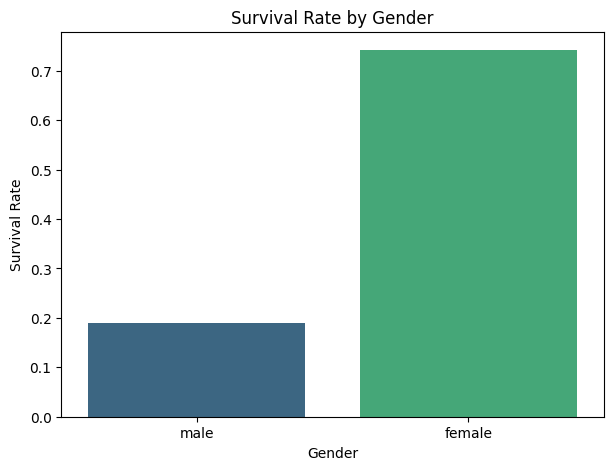

In [24]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

#### Visual 2: Bar chart of survival by passenger class

C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\1623235301.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')
C:\Users\Rebit Ranjan\AppData\Local\Temp\ipykernel_7976\1623235301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')


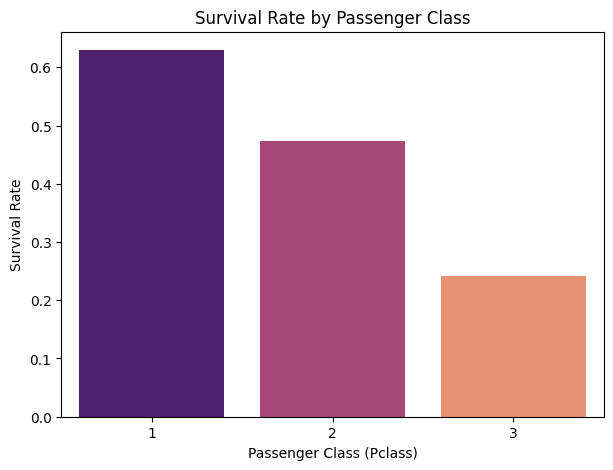

In [26]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Survival Rate')
plt.show()

### Visual 3: Histogram of passenger ages

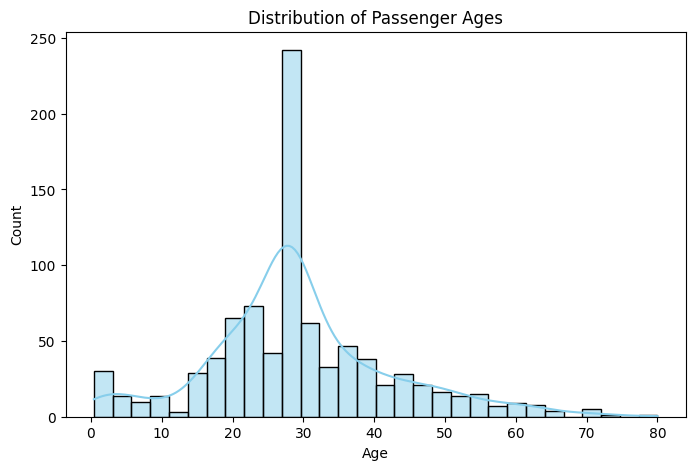

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()